352
nombre d'options: 352


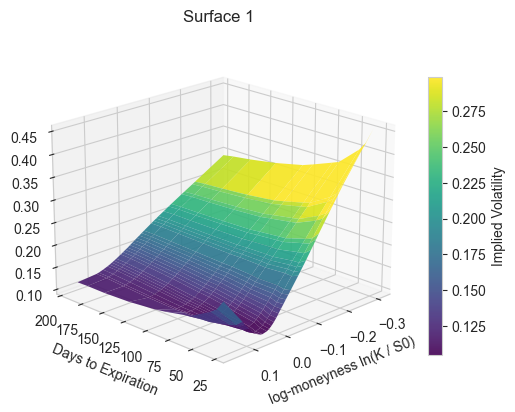

In [1]:
from utils import get_options_data, filter_df
from vol_surface import Vol_Surface, max_area_complete_grid
from heston_pricing import HestonParams, Config, HestonCalibration

ticker = "SPY"
date = "2025-12-19"
config = Config(ticker, date)

raw_df = get_options_data(config)
df = filter_df(raw_df)

K_grid, tau_grid = max_area_complete_grid(df)
df = df[df["strike"].isin(K_grid) & df["tau"].isin(tau_grid)]
vol_surface = Vol_Surface(config)

vol_surface.volatility_surface([df])

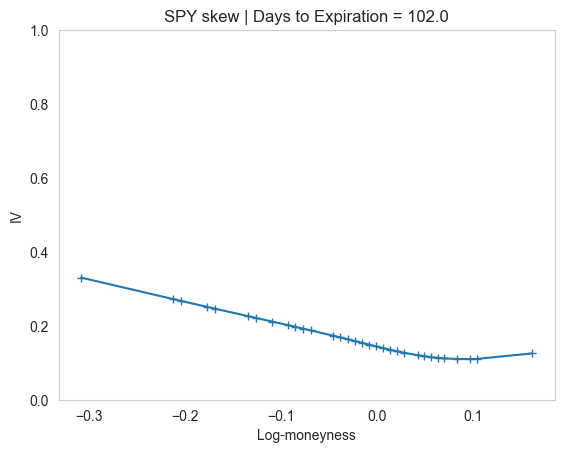

In [2]:
vol_surface.skew(df, daysToExpiration=100, visual="log-moneyness")

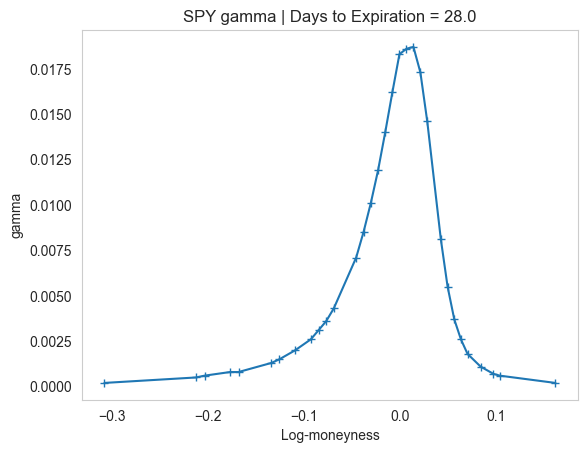

In [3]:
vol_surface.greeks(df, greek="gamma", daysToExpiration= 10)

In [4]:
heston_calibration = HestonCalibration(df=df, raw_df=raw_df, config=config)
theta0 = HestonParams(kappa=3.0, v_bar=0.1, sigma=0.25, rho=-0.8, v0=0.08)

thetaf = heston_calibration.LM_algorithm(theta0=theta0, max_iter=20)

deltaF 40418.24425336268 deltaL 43240.050994202196 norm 297.61682048322456
step accepted
deltaF 3718.571950043727 deltaL 3649.979639522021 norm 87.97319664431059
step accepted
deltaF 91.2953429840411 deltaL 90.23677008440639 norm 17.382158316247306
step accepted
deltaF 9.25075829032108 deltaL 9.219207296790719 norm 10.933834723600096
step accepted
deltaF 6.03806074118252 deltaL 6.014744331934052 norm 10.052224887176024
step accepted
deltaF 4.876430796542728 deltaL 4.863298162086476 norm 9.43244950688823
step accepted
deltaF 4.135293516051057 deltaL 4.128791122204699 norm 8.900463027669433
step accepted
deltaF 3.5384705801557423 deltaL 3.535842391152193 norm 8.423043100614434
step accepted
deltaF 3.0300783171692736 deltaL 3.0296336460137194 norm 7.991915534744905
step accepted
deltaF 2.5939621654842107 deltaL 2.5946817584579382 norm 7.603325409329683
step accepted
deltaF 2.220754999356302 deltaL 2.222025974429831 norm 7.254145914522947
step accepted
deltaF 1.9023315469698794 deltaL 1.90

352
nombre d'options: 352
352
nombre d'options: 352
352
nombre d'options: 352


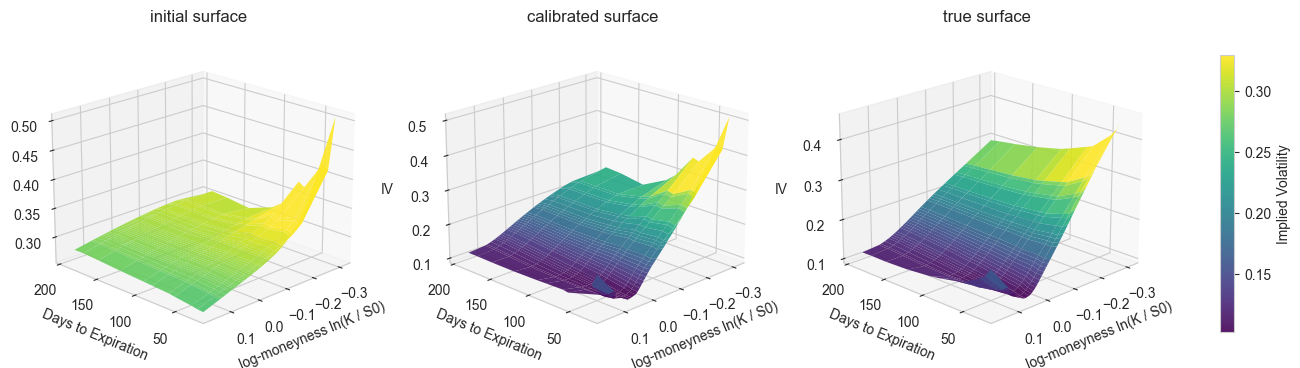

In [5]:
init_df, calib_df = heston_calibration.compute_iv_surface(theta0, thetaf,  K_grid, tau_grid)

vol_surface.volatility_surface([init_df, calib_df, df], titles=["initial surface", "calibrated surface", "true surface"])